# Практическая работа 3. ML-пайплайн на больших данных — Spark MLlib

**Савкина Мария Алексеевна, БД-251м**

**Вариант 25 (5)**

| Параметр | Значение |
|---|---|
| Задание 1 | Создание признаков duration, avg_heart_rate, target: `calories` (синтетическая) |
| Задание 2 | Модель регрессии `Linear Regression` |
| Задание 3 | Оценка качества (RMSE, R²) и анализ надежности модели |

**Бизнес-кейс:** Data Scientist в компании HealthTech — разработать модель для оценки количества сожжённых калорий на основе данных тренировок пользователей.

**Структура:** `Setup → Download → ETL → Feature Engineering → Pipeline → Evaluation → Visualization → Business`

## 0. Setup — Установка зависимостей

In [1]:
import sys
!{sys.executable} -m pip install pyspark gdown findspark matplotlib seaborn scikit-learn --quiet
print('✅ Зависимости установлены')

✅ Зависимости установлены


In [79]:
import os, shutil, time, warnings
warnings.filterwarnings('ignore')

import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder,
                                 VectorAssembler, StandardScaler)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.regression import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.linalg import DenseVector

print(f'✅ PySpark: {pyspark.__version__}')

✅ PySpark: 4.0.2


## 1. Загрузка данных

In [3]:
DATA_DIR = 'data'
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
    print(f'🗑️  Каталог {DATA_DIR!r} удалён')
os.makedirs(DATA_DIR)
print(f'📁 Каталог {DATA_DIR!r} создан')

📁 Каталог 'data' создан


In [4]:
import gdown, zipfile, os

DATA_DIR    = "data"
ZIP_PATH    = os.path.join(DATA_DIR, "endomondoHR.zip")
OUTPUT_PATH = os.path.join(DATA_DIR, "endomondoHR.json")

# Очистка и создание каталога
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)
print(f"📁 Каталог '{DATA_DIR}' пересоздан")

# Скачивание
FILE_ID = "1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe"
print("⬇️  Скачивание с Google Drive...")
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID}&confirm=t",
    ZIP_PATH,
    quiet=False
)
print(f"✅ Скачано: {os.path.getsize(ZIP_PATH)/1024/1024:.1f} МБ")

# Распаковка
print("📦 Распаковка архива...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    print(f"   Содержимое: {zf.namelist()}")
    zf.extractall(DATA_DIR)

# Проверяем что JSON появился
if not os.path.exists(OUTPUT_PATH):
    # иногда внутри архива другое имя — берём первый json
    for f in os.listdir(DATA_DIR):
        if f.endswith(".json"):
            os.rename(os.path.join(DATA_DIR, f), OUTPUT_PATH)
            break

print(f"✅ Готово: {OUTPUT_PATH}")
print(f"   Размер JSON: {os.path.getsize(OUTPUT_PATH)/1024/1024:.1f} МБ")

📁 Каталог 'data' пересоздан
⬇️  Скачивание с Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe&confirm=t
To: /content/data/endomondoHR.zip
100%|██████████| 2.02G/2.02G [00:33<00:00, 60.2MB/s]


✅ Скачано: 1926.0 МБ
📦 Распаковка архива...
   Содержимое: ['endomondoHR.json']
✅ Готово: data/endomondoHR.json
   Размер JSON: 6264.1 МБ


## 2. Инициализация SparkSession

In [5]:
spark = (SparkSession.builder
    .appName('HealthTech_GenderPredictor_V20')
    .config('spark.driver.memory', '8g')
    .config('spark.sql.shuffle.partitions', '50')
    .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')
print(f'SparkSession: v{spark.version}; App: {spark.sparkContext.appName}')

SparkSession: v4.0.2; App: HealthTech_GenderPredictor_V20


In [6]:
raw_df = spark.read.json(OUTPUT_PATH).cache()

print(f"Схема:\n{raw_df._jdf.schema().treeString()}")
print(f"Записей (сырых): {raw_df.count():,}")

raw_df.show(3, truncate=80, vertical=False)

Схема:
root
 |-- altitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- gender: string (nullable = true)
 |-- heart_rate: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- id: long (nullable = true)
 |-- latitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- longitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- speed: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- url: string (nullable = true)
 |-- userId: long (nullable = true)

Записей (сырых): 253,020
+--------------------------------------------------------------------------------+------+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+----

## 3. ETL — Загрузка, исследование и очистка данных

### 3.1 Загрузка JSON

In [45]:
# Пропущенные значения
print('Анализ пропущенных значений:')

key_cols = ['timestamp', 'heart_rate', 'sport', 'gender', 'speed', 'userId']

total = raw_df.count()

for c in key_cols:
    null_cnt = raw_df.filter(F.col(c).isNull()).count()
    print(f'  {c:15s}: {null_cnt:6,} null  ({null_cnt/total*100:.1f}%)')

Анализ пропущенных значений:
  timestamp      :      0 null  (0.0%)
  heart_rate     :      0 null  (0.0%)
  sport          :      0 null  (0.0%)
  gender         :      0 null  (0.0%)
  speed          : 203,360 null  (80.4%)
  userId         :      0 null  (0.0%)


In [46]:
# Статистика длин массивов временных рядов и пульса
raw_df.select(
    F.size("timestamp").alias("ts_len"),
    F.size("heart_rate").alias("hr_len"),
).describe().show()

+-------+------------------+------------------+
|summary|            ts_len|            hr_len|
+-------+------------------+------------------+
|  count|            253020|            253020|
|   mean|440.84244723737254|440.84244723737254|
| stddev|125.16138207242905|125.16138207242905|
|    min|                 1|                 1|
|    max|               500|               500|
+-------+------------------+------------------+



In [47]:
# Количество коротких тренировок с одним замером
total_count = raw_df.count()
short_trainings = raw_df.filter(F.size('timestamp') <= 1).count()

print(f"Всего записей: {total_count}")
print(f"Записей с одним замером (duration при расчёте будет равен 0): {short_trainings}")
print(f"Доля 'пустых' тренировок (с одним замером): {round(short_trainings/total_count*100, 2)}%")

# Анализ распределения длительности тренировок через разность timestamp
raw_df.select(
    ((F.array_max("timestamp") - F.array_min("timestamp")) / 60).alias("duration")
).describe().show()


Всего записей: 253020
Записей с одним замером (duration при расчёте будет равен 0): 120
Доля 'пустых' тренировок (с одним замером): 0.05%
+-------+------------------+
|summary|          duration|
+-------+------------------+
|  count|            253020|
|   mean|451.19641326113873|
| stddev| 41235.65476521412|
|    min|               0.0|
|    max|         9908696.1|
+-------+------------------+



In [48]:
# Минимальные и максимальные значения пульса
raw_df.select(
    F.expr("array_min(heart_rate)").alias("min_hr"),
    F.expr("array_max(heart_rate)").alias("max_hr")
).describe().show()

+-------+-----------------+------------------+
|summary|           min_hr|            max_hr|
+-------+-----------------+------------------+
|  count|           253020|            253020|
|   mean|87.35471504228914|163.69484230495613|
| stddev|21.52641138896453| 43.67432870748153|
|    min|            -2604|              -135|
|    max|              242|             18514|
+-------+-----------------+------------------+



## Выводы:
- Пропущенные значения присутствуют только в столбце `speed`.

- Есть треки с только одним измерением пульса. Для duration и среднего пульса такие треки почти бесполезны, то есть необходима фильтрация коротких треков.

- Однако записей с одним замером мало - всего 0.05%, то есть большинство тренировок пригодны для расчёта необходимых признаков.

- Выявлены аномальные значения (min, max), нужна очистка аномальных значений пульса

### 3.2 Очистка данных

In [52]:
df_clean = (raw_df
    .filter(F.size("timestamp") >= 10)                                                          # минимум 10 точек timestamp (ключевое поле)
    .filter(F.size("heart_rate") >= 10)                                                         # минимум 10 точек heart_rate (ключевое поле)
    .filter(F.size(F.col('speed')) >= 10)                                                       # минимум 10 точек скорости (избавляемся от пустых значений)
    .filter(F.expr("forall(heart_rate, x -> x >= 40 AND x <= 220)"))                            # корректные значения пульса
    .filter(((F.array_max("timestamp") - F.array_min("timestamp")) / 60) <= 1000)               # фильтр по длительности в минутах (само поле duration будет создано далее)
    .filter(F.col('gender').isin('male', 'female'))                                             # только валидные значения
)

n_raw   = raw_df.count()
n_clean = df_clean.count()
print(f'После очистки: {n_clean:,} из {n_raw:,} ({n_clean/n_raw*100:.1f}%)')

После очистки: 48,283 из 253,020 (19.1%)


## 4. Feature Engineering — Конструирование признаков

### 4.1 Концептуальное скользящее среднее пульса

Поля `heart_rate` и `timestamp` — массивы измерений за тренировку. Для создания признаков используем следующие подходы:

- `duration` — длительность тренировки, рассчитанная как разница между максимальным и минимальным временем в массиве `timestamp`.

- `avg_heart_rate` — среднее значение пульса за тренировку, рассчитанное как среднее по всем элементам массива `heart_rate`.

Синтетическая целевая переменная `calories` формируется на основе этих признаков по формуле:

$$calories = \frac{duration \cdot avg\_heart\_rate}{100}$$

In [53]:
df_features = df_clean.withColumn(
    "duration", (F.array_max("timestamp") - F.array_min("timestamp")) / 60        #Делим на 60, чтобы получить длительность тренировки в минутах
).withColumn(
    "avg_heart_rate", F.expr("aggregate(heart_rate, 0D, (acc, x) -> acc + x) / size(heart_rate)")
).withColumn(
    "calories", F.col("duration") * F.col("avg_heart_rate") / 100
)

# Проверка первых 5 записей
df_features.select("duration", "avg_heart_rate", "calories").show(5)

print(f'Итого: {df_features.count():,} строк, {len(df_features.columns)} колонок')
df_features.describe().show()

+------------------+--------------+------------------+
|          duration|avg_heart_rate|          calories|
+------------------+--------------+------------------+
|126.48333333333333|        152.65|193.07680833333336|
|              74.0|        147.71|          109.3054|
|112.48333333333333|       140.554|158.09982433333334|
| 75.31666666666666|        147.02|110.73056333333334|
|             23.75|       166.084|          39.44495|
+------------------+--------------+------------------+
only showing top 5 rows
Итого: 48,283 строк, 14 колонок
+-------+------+--------------------+--------+--------------------+-----------------+-----------------+------------------+-------------------+
|summary|gender|                  id|   sport|                 url|           userId|         duration|    avg_heart_rate|           calories|
+-------+------+--------------------+--------+--------------------+-----------------+-----------------+------------------+-------------------+
|  count| 48283|    

In [60]:
# Преобразование массивов, создание агрегатов
df_features = df_clean.select(
    F.col('gender'),
    F.col('sport'),

    # Heart Rate — базовые агрегаты
    F.aggregate('heart_rate', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('heart_rate')).alias('hr_mean'),

    F.array_max(F.col('heart_rate').cast('array<double>')).alias('hr_max'),
    F.array_min(F.col('heart_rate').cast('array<double>')).alias('hr_min'),
    (F.array_max(F.col('heart_rate').cast('array<double>')) -
     F.array_min(F.col('heart_rate').cast('array<double>'))).alias('hr_range'),

    # Duration (в минутах)
    ((F.array_max('timestamp') - F.array_min('timestamp')) / 60).alias('duration'),

    # Speed
    F.aggregate('speed', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('speed')).alias('avg_speed'),

    # Altitude - перепад высоты
    (F.array_max(F.col('altitude').cast('array<double>')) -
     F.array_min(F.col('altitude').cast('array<double>'))).alias('altitude_delta'),

    # Target - calories
    (
        ((F.array_max('timestamp') - F.array_min('timestamp')) / 60) *
        F.aggregate('heart_rate', F.lit(0.0),
                    lambda acc, x: acc + x.cast('double'),
                    lambda acc: acc / F.size('heart_rate')) / 100
    ).alias('calories')
)

df_features.show(5)

+------+----------------+-------+------+------+--------+------------------+------------------+------------------+------------------+
|gender|           sport|hr_mean|hr_max|hr_min|hr_range|          duration|         avg_speed|    altitude_delta|          calories|
+------+----------------+-------+------+------+--------+------------------+------------------+------------------+------------------+
|  male|            bike| 152.65| 177.0| 100.0|    77.0|126.48333333333333|26.162157600000004|              59.6|193.07680833333336|
|  male|            bike| 147.71| 174.0| 100.0|    74.0|              74.0|27.218368800000004|50.599999999999994|          109.3054|
|  male|            bike|140.554| 168.0|  99.0|    69.0|112.48333333333333|26.050773600000017|              60.6|158.09982433333334|
|  male|            bike| 147.02| 178.0|  99.0|    79.0| 75.31666666666666| 26.87783759999997|              51.6|110.73056333333334|
|  male|bike (transport)|166.084| 185.0| 118.0|    67.0|             

### 4.2 ML-трансформеры для Pipeline

In [61]:
# Кодирование категориальных признаков с помощью StringIndexer (из текста в числа) и OneHotEncoder (из чисел в векторы)
categorical_cols = ["gender", "sport"]
indexers = [StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_ohe") for col in categorical_cols]

# Числовые признаки
numeric_cols = [
    "duration",
    "hr_mean",
    "hr_max",
    "hr_min",
    "hr_range",
    "avg_speed",
    "altitude_delta"
]

# Объединяем все признаки в один вектор
assembler = VectorAssembler(
    inputCols=numeric_cols + [col + "_ohe" for col in categorical_cols],
    outputCol="features"
)

# Масштабирование признаков
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

# Итоговый пайплайн
stages = indexers + encoders + [assembler, scaler]
pipeline = Pipeline(stages=stages)
print('✅ Трансформеры сконфигурированы')
print(f'   Числовые признаки: {len(numeric_cols)}')

✅ Трансформеры сконфигурированы
   Числовые признаки: 7


## 5. ML Pipeline — Обучение модели

### 5.1 Разбивка на train/test (80/20)

In [62]:
# Разбиение на train и test (80/20)
train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=42)

print(f'Train: {train_df.count():,};  Test: {test_df.count():,}')


Train: 38,637;  Test: 9,646


### 5.2 Обучение модели Linear Regression (Задание 2).

In [65]:
# Обучаем pipeline на train
pipeline_model = pipeline.fit(train_df)

# Применяем трансформации
train_prepared = pipeline_model.transform(train_df)
test_prepared = pipeline_model.transform(test_df)

lr = LinearRegression(
    featuresCol="scaled_features",
    labelCol="calories"
)

# Обучение модели
lr_model = lr.fit(train_prepared)

predictions = lr_model.transform(test_prepared)

print('Модель успешно обучена')
predictions.select("calories", "prediction").show(10)

Модель успешно обучена
+------------------+------------------+
|          calories|        prediction|
+------------------+------------------+
| 89.73527588510355| 91.47335334722203|
| 87.89337341349365| 89.29013783929523|
|        108.032932|110.65403607801917|
|114.79009500000001|117.69169486235532|
|         70.793268| 71.17618786762588|
|31.759211768851305|30.860937963873113|
|33.717760000000006| 32.49269458940498|
|        239.916625|241.37223976267313|
|          42.21634|42.321652579773314|
|22.520886440677963|23.772545020446245|
+------------------+------------------+
only showing top 10 rows


## 6. Оценка модели (Evaluation)

In [69]:
print("Оценка модели Linear Regression:")

# RMSE (по заданию варианта)
evaluator_rmse = RegressionEvaluator(
    labelCol="calories",
    predictionCol="prediction",
    metricName="rmse"
)
rmse = evaluator_rmse.evaluate(predictions)
print(f"RMSE: {rmse:.2f}")

# r2 (по заданию варианта)
evaluator_r2 = RegressionEvaluator(
    labelCol="calories",
    predictionCol="prediction",
    metricName="r2"
)
r2 = evaluator_r2.evaluate(predictions)
print(f"R²:   {r2:.4f}")

# mae
evaluator_mae = RegressionEvaluator(
    labelCol="calories",
    predictionCol="prediction",
    metricName="mae"
)
mae = evaluator_mae.evaluate(predictions)
print(f"MAE:  {mae:.2f}")

# mse
evaluator_mse = RegressionEvaluator(
    labelCol="calories",
    predictionCol="prediction",
    metricName="mse"
)
mse = evaluator_mse.evaluate(predictions)
print(f"MSE:  {mse:.2f}")

Оценка модели Linear Regression:
RMSE: 12.08
R²:   0.9899
MAE:  6.68
MSE:  145.85


## Интерпретация метрик

- `RMSE = 12.08 калорий` - среднеквадратичная ошибка предсказаний невелика, редкие отклонения от реальных значений небольшие.
- `MAE = 6.68 калорий` - в среднем предсказания отличаются от истинных значений всего примерно на 7 калорий.
- `R² = 0.9899` — модель объясняет почти 99% вариации данных, прогнозы очень точные.
- `MSE = 145.85` — крупные ошибки встречаются редко, разброс предсказаний небольшой.

In [76]:
  # Оценка важности признаков
  # Коэффициенты линейной регрессии
  coefficients = lr_model.coefficients

  # Имена признаков из VectorAssembler
  assembler = pipeline_model.stages[-2]
  feature_cols = assembler.getInputCols()

  # Список признаков с коэффициентами
  feature_importance = [(feature, coef) for feature, coef in zip(feature_cols, coefficients)]

  # Сортировка по модулю (абс. значению)
  feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

  print("Важность признаков (по абсолютной величине коэффициента):")
  for feature, coef in feature_importance_sorted:
      print(f"{feature}: {coef:.4f}")

Важность признаков (по абсолютной величине коэффициента):
duration: 115.7596
hr_mean: 13.6266
hr_max: -1.4345
hr_min: -0.9277
avg_speed: -0.7603
altitude_delta: 0.3815
hr_range: -0.3712
sport_ohe: -0.0328
gender_ohe: 0.0328


## Оценка важности признаков

- Наибольшее влияние на предсказание калорий оказывает duration — длительность активности, её коэффициент значительно выше остальных.
- `hr_mean` (средний пульс) также существенно влияет на прогноз.
Остальные числовые признаки (`hr_max`, `hr_min`, `avg_speed`, `altitude_delta`, `hr_range`) оказывают меньшее влияние, но всё ещё учитываются моделью.
- Категориальные признаки (`sport`, `gender`) имеют минимальное влияние на предсказания, что отражает их относительно небольшую роль в модели.

## 7. Визуализация результатов

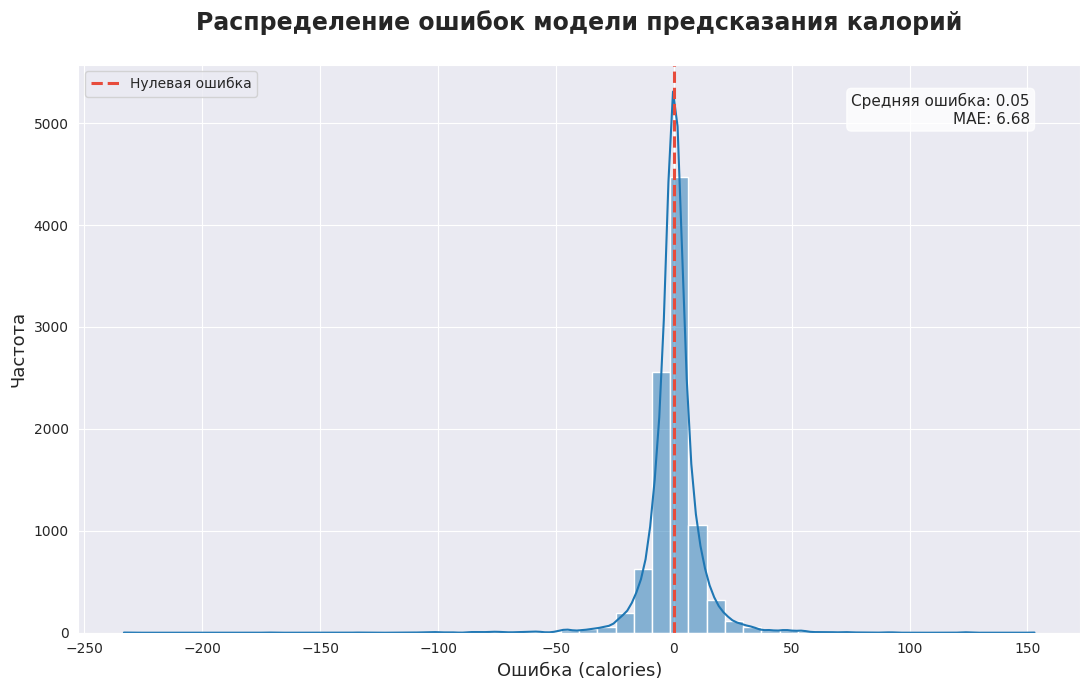

In [90]:
# Распределение ошибок модели предсказания калорий
sns.set_style("darkgrid")
plt.figure(figsize=(11, 7))

sns.histplot(
    pred_df["error"],
    bins=50,
    kde=True
)

plt.axvline(0, color='#e74c3c', linestyle='--', linewidth=2.2, label='Нулевая ошибка')

plt.title("Распределение ошибок модели предсказания калорий",
          fontsize=17, fontweight='bold', pad=25)
plt.xlabel("Ошибка (calories)", fontsize=13)
plt.ylabel("Частота", fontsize=13)

# Добавляем текст со статистикой прямо на график
stats_text = f"Средняя ошибка: {pred_df['error'].mean():.2f}\n" \
             f"MAE: {abs(pred_df['error']).mean():.2f}"

plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

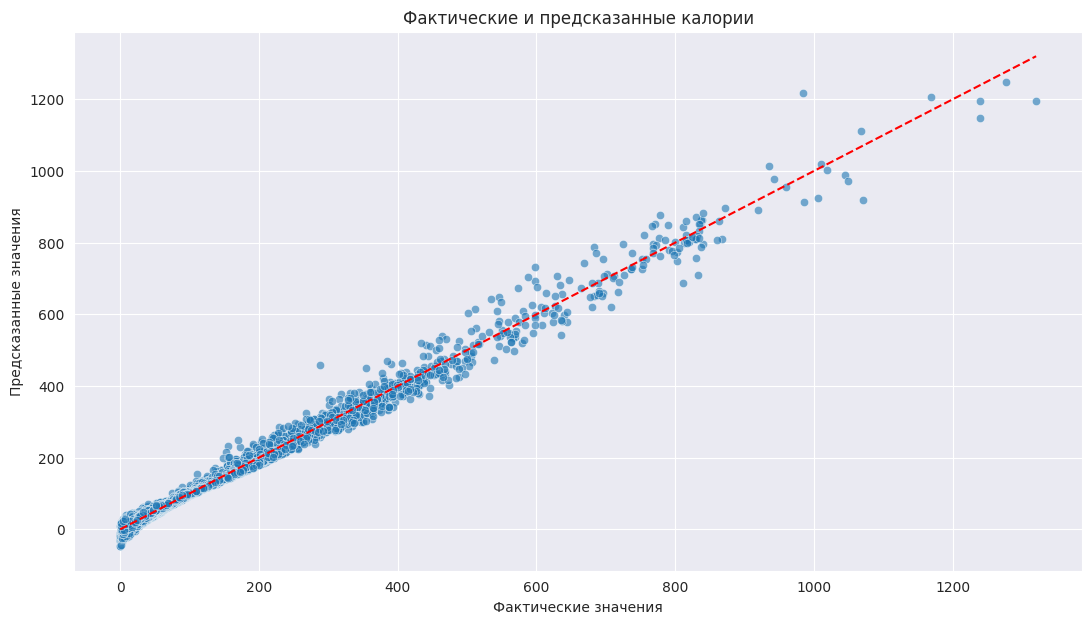

In [95]:
# Фактические и предсказанные калории
plt.figure(figsize=(13, 7))
sns.scatterplot(x="calories", y="prediction", data=pred_df, alpha=0.6)
plt.plot([pred_df.calories.min(), pred_df.calories.max()],
         [pred_df.calories.min(), pred_df.calories.max()],
         color='red', linestyle='--')  # линия y=x
plt.title("Фактические и предсказанные калории")
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.show()

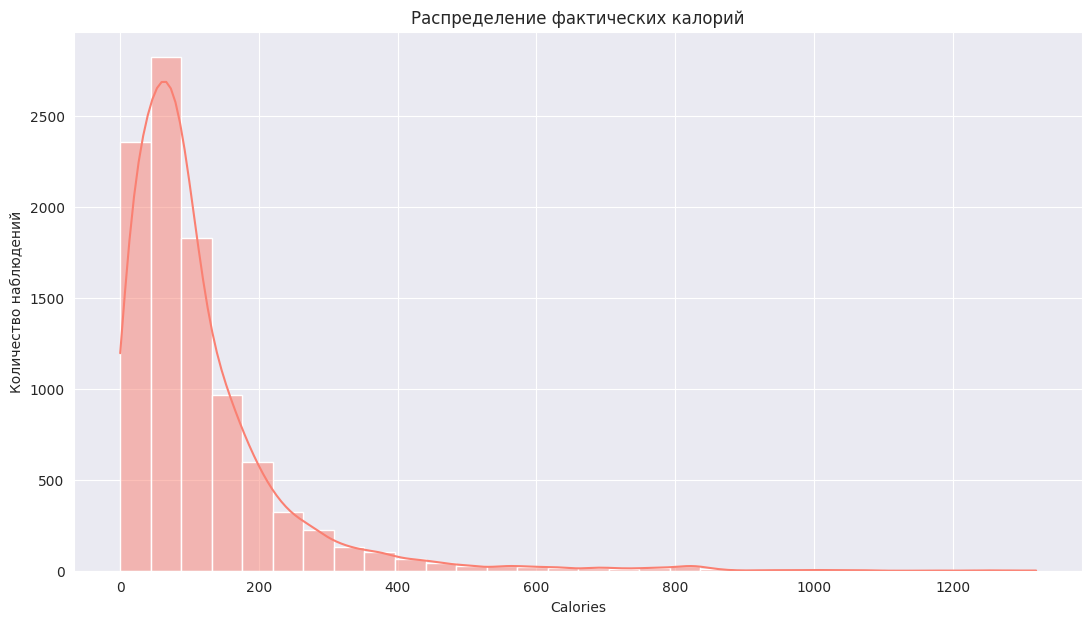

In [96]:
# Распределение фактических калорий
plt.figure(figsize=(13, 7))
sns.histplot(pred_df["calories"], bins=30, kde=True, color="salmon")
plt.title("Распределение фактических калорий")
plt.xlabel("Calories")
plt.ylabel("Количество наблюдений")
plt.show()

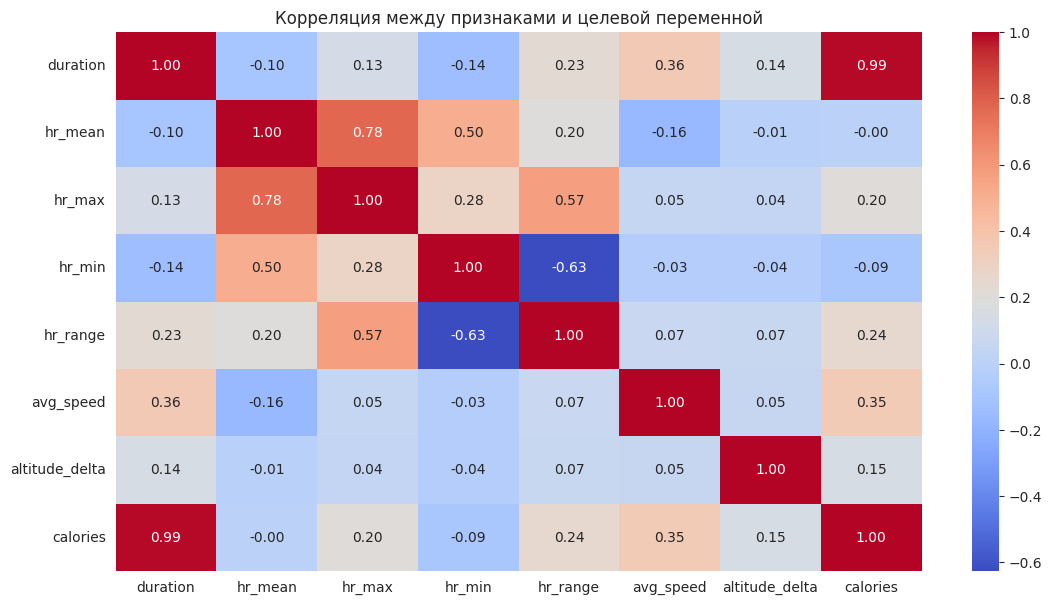

In [98]:
# Кореляционная матрица
plt.figure(figsize=(13, 7))
numeric_df = train_df.select(numeric_cols + ["calories"]).toPandas()
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция между признаками и целевой переменной")
plt.show()

## 8. Бизнес-интерпретация (Задание 3)

### Вопрос. Насколько надежна такая модель для медицинских рекомендаций?

Уточнение (P.S) - целевой признак является синтетической целью. Поэтому, с целью сохранения бизнес-логики, при интерпретации данный будем рассматривать данные как "настоящие".

In [102]:
# Определяем топ-2 признака по абсолютной величине коэффициента
top_features = [feature for feature, coef in feature_importance_sorted[:2]]

# Генерация текста бизнес-вывода
business_summary = f"""
Модель линейной регрессии для предсказания калорий на основе признаков активности показывает высокую точность:

R² = {r2:.4f} - почти {r2*100:.0f}% вариации калорий объясняется моделью.
RMSE = {rmse:.2f} и MAE = {mae:.2f} калорий - ошибки предсказания минимальны, что означает, что пользователи будут получать практически точные рекомендации по сжигаемым калориям.

Важность признаков показывает, что основные драйверы калорий — это {top_features[0]} и {top_features[1]}. Остальные признаки имеют вспомогательное влияние, а категориальные признаки (sport, gender) практически не влияют на результат.

💡 Бизнес-ценность:

Благодаря высокой точности модель позволяет персонализировать рекомендации по сжиганию калорий, что повышает удовлетворённость пользователей и, косвенно, удержание и прибыль продукта.
Продукт может давать точные советы по тренировкам и контролю калорий, что важно для фитнес-приложений и wearables.
Однако высокая точность заставляет задуматься о проблеме переобучения, т.к. в реальной жизни данные изменчивы: разные пользователи, ошибки измерений, неточные сенсоры.

Надёжность для медицинских рекомендаций:

Модель демонстрирует очень высокий R² и низкие ошибки, что делает её надёжной для оценки калорий и рекомендаций по активности в фитнес-контексте.
Однако в данном случае модель может не учитывать естественный разброс, что опасно для решений, где нужна осторожность (например, медицинские рекомендации).
То есть для строгих медицинских рекомендаций, особенно для пациентов с заболеваниями сердца или другими критическими состояниями, полагаться только на эту модель не рекомендуется.
"""

print(business_summary)


Модель линейной регрессии для предсказания калорий на основе признаков активности показывает высокую точность:

R² = 0.9899 - почти 99% вариации калорий объясняется моделью.
RMSE = 12.08 и MAE = 6.68 калорий - ошибки предсказания минимальны, что означает, что пользователи будут получать практически точные рекомендации по сжигаемым калориям.

Важность признаков показывает, что основные драйверы калорий — это duration и hr_mean. Остальные признаки имеют вспомогательное влияние, а категориальные признаки (sport, gender) практически не влияют на результат.

💡 Бизнес-ценность:

Благодаря высокой точности модель позволяет персонализировать рекомендации по сжиганию калорий, что повышает удовлетворённость пользователей и, косвенно, удержание и прибыль продукта. 
Продукт может давать точные советы по тренировкам и контролю калорий, что важно для фитнес-приложений и wearables.
Однако высокая точность заставляет задуматься о проблеме переобучения, т.к. в реальной жизни данные изменчивы: разные п